# Experiments
### PAC Learning & VC Dimension · Generalized Linear Models · Regression with Correlated Data · Regularization



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from math import comb

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. PAC Learning & VC Dimension

### 1.1 Shattering: linear classifiers in $\mathbb{R}^2$ have VC dimension 3

Section 3.2 (Example 3.2) of the notes claims $\text{VCdim} = d+1$ for linear classifiers in
$\mathbb{R}^d$: any 3 points in general position in $\mathbb{R}^2$ can be shattered by a line, but
no 4 points can. We check this directly: for 3 points, fit a linear SVM (hard-margin) to *every one*
of the $2^3=8$ possible labelings and confirm each is perfectly separable. Then we try the
XOR-labeled square (4 points) and confirm it is **not** separable.

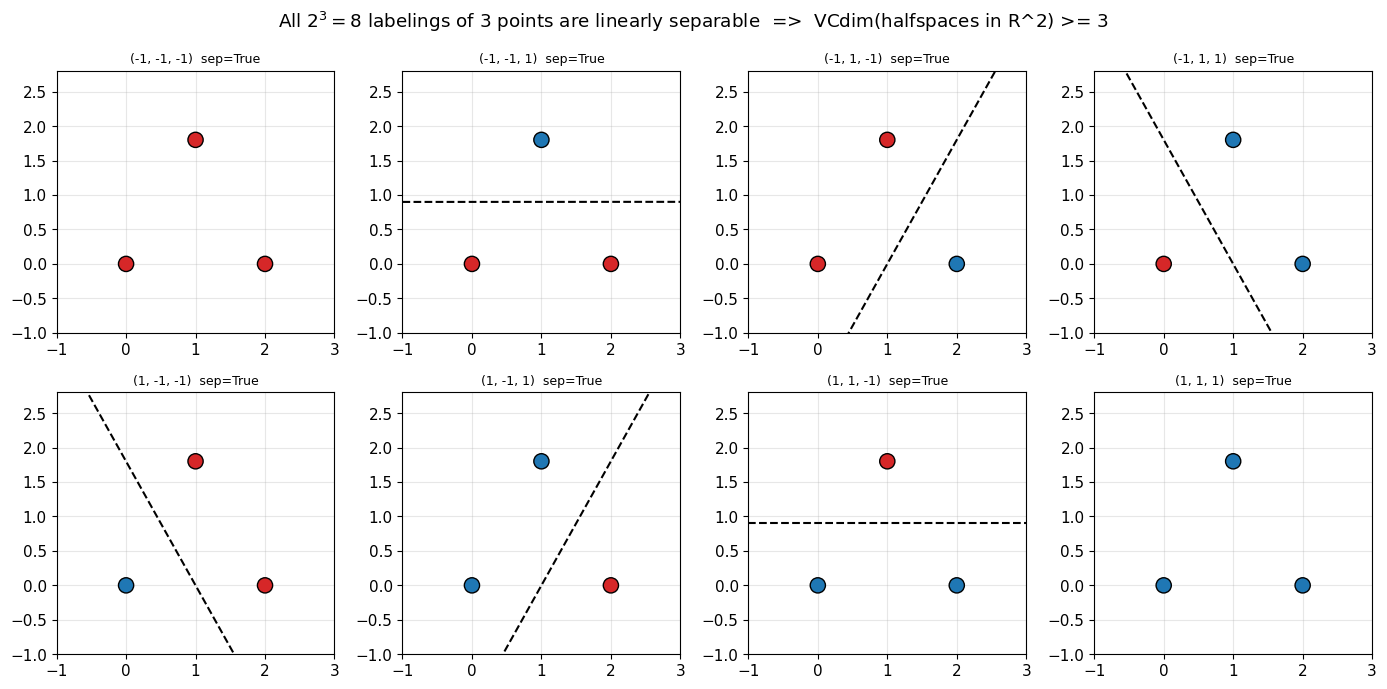

All 8 labelings separable: True


In [2]:
from sklearn.svm import SVC

def is_separable(points, labels):
    # Fit a hard-margin linear SVM and check it achieves 100% train accuracy.
    if len(set(labels)) == 1:
        return True, None
    clf = SVC(kernel='linear', C=1e6)
    clf.fit(points, labels)
    return clf.score(points, labels) == 1.0, clf

def plot_boundary(ax, points, labels, clf, sep):
    colors = ['tab:red' if l == -1 else 'tab:blue' for l in labels]
    ax.scatter(points[:, 0], points[:, 1], c=colors, s=120, edgecolor='k', zorder=3)
    if clf is not None:
        w, b = clf.coef_[0], clf.intercept_[0]
        xx = np.linspace(points[:, 0].min() - 1, points[:, 0].max() + 1, 50)
        if abs(w[1]) > 1e-6:
            ax.plot(xx, -(w[0] * xx + b) / w[1], 'k--', linewidth=1.5)
        elif abs(w[0]) > 1e-6:
            ax.axvline(-b / w[0], color='k', linestyle='--')
    ax.set_title(f"{tuple(int(l) for l in labels)}  sep={sep}", fontsize=9)
    ax.set_xlim(points[:, 0].min() - 1, points[:, 0].max() + 1)
    ax.set_ylim(points[:, 1].min() - 1, points[:, 1].max() + 1)

points3 = np.array([[0, 0], [2, 0], [1, 1.8]])          # triangle: general position
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
all_sep = True
for ax, labels in zip(axes.flat, product([-1, 1], repeat=3)):
    labels = np.array(labels)
    sep, clf = is_separable(points3, labels)
    all_sep &= sep
    plot_boundary(ax, points3, labels, clf, sep)
plt.suptitle("All $2^3=8$ labelings of 3 points are linearly separable  =>  VCdim(halfspaces in R^2) >= 3")
plt.tight_layout()
plt.show()
print("All 8 labelings separable:", all_sep)


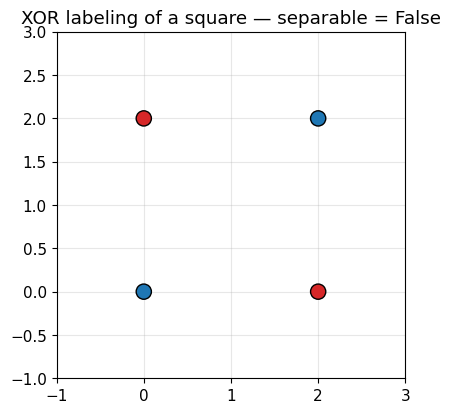

VCdim(halfspaces in R^2) = 3, since this labeling of 4 points cannot be realized: True


In [3]:
points4 = np.array([[0, 0], [2, 0], [0, 2], [2, 2]])   # square
xor_labels = np.array([1, -1, -1, 1])                    # diagonal (XOR) labeling

sep, clf = is_separable(points4, xor_labels)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
plot_boundary(ax, points4, xor_labels, clf, sep)
ax.set_title(f"XOR labeling of a square — separable = {sep}")
plt.show()
print("VCdim(halfspaces in R^2) = 3, since this labeling of 4 points cannot be realized:", not sep)


### 1.2 Generalization gap shrinks with $m$, at roughly the VC-predicted rate

Theorem 3.1 in the notes predicts $R(h) - \hat R_S(h) = O(\sqrt{d/m})$ for a hypothesis class of
VC dimension $d$. We train a linear classifier (logistic regression, $d{=}2$ features so
$\text{VCdim}=d+1=3$) on increasing amounts of data and track $|\text{test error} - \text{train
error}|$, averaged over many random draws, against the $\sqrt{3/m}$ curve.

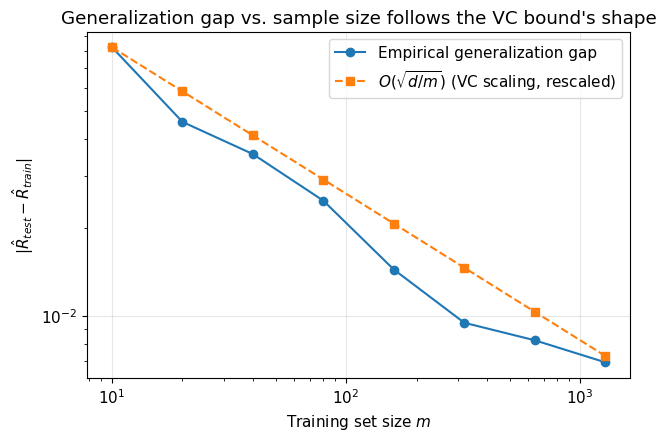

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

def generalization_gap(m_values, n_trials=40, d=2):
    gaps = []
    for m in m_values:
        trial_gaps = []
        for _ in range(n_trials):
            X, y = make_classification(n_samples=m + 3000, n_features=d, n_informative=d,
                                        n_redundant=0, n_clusters_per_class=1, flip_y=0.05,
                                        class_sep=1.2)
            X_train, y_train, X_test, y_test = X[:m], y[:m], X[m:], y[m:]
            clf = LogisticRegression().fit(X_train, y_train)
            train_err = 1 - clf.score(X_train, y_train)
            test_err = 1 - clf.score(X_test, y_test)
            trial_gaps.append(abs(test_err - train_err))
        gaps.append(np.mean(trial_gaps))
    return np.array(gaps)

m_values = [10, 20, 40, 80, 160, 320, 640, 1280]
gaps = generalization_gap(m_values)

vc_dim = 3  # d + 1, d = 2 input features
theory = np.sqrt(vc_dim / np.array(m_values, dtype=float))
theory *= gaps[0] / theory[0]   # rescale to compare shape, not absolute constant

plt.figure()
plt.plot(m_values, gaps, 'o-', label='Empirical generalization gap')
plt.plot(m_values, theory, 's--', label=r'$O(\sqrt{d/m})$ (VC scaling, rescaled)')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Training set size $m$'); plt.ylabel(r'$|\hat{R}_{test} - \hat{R}_{train}|$')
plt.legend(); plt.title('Generalization gap vs. sample size follows the VC bound\'s shape')
plt.show()


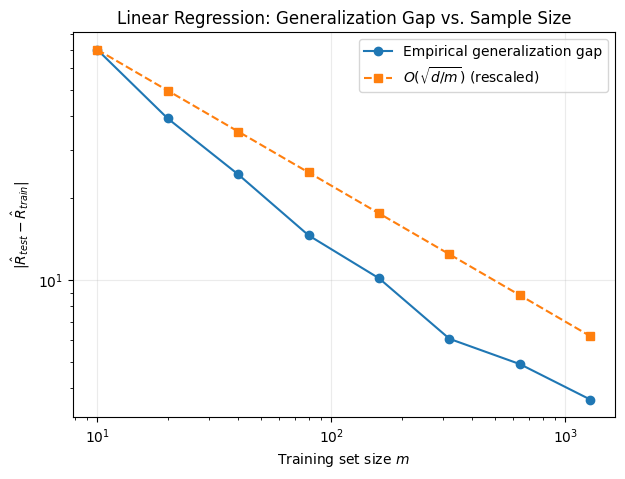

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error


def generalization_gap_linear(m_values, n_trials=40, d=2):

    gaps = []

    for m in m_values:

        trial_gaps = []

        for _ in range(n_trials):

            # Generate regression data
            X, y = make_regression(
                n_samples=m + 3000,
                n_features=d,
                n_informative=d,
                noise=10.0,
                random_state=None
            )

            # Split into training and test
            X_train = X[:m]
            y_train = y[:m]

            X_test = X[m:]
            y_test = y[m:]

            # Fit linear regression
            model = LinearRegression()
            model.fit(X_train, y_train)

            # Predictions
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

            # Train and test MSE
            train_mse = mean_squared_error(
                y_train,
                y_train_pred
            )

            test_mse = mean_squared_error(
                y_test,
                y_test_pred
            )

            # Generalization gap
            gap = abs(test_mse - train_mse)

            trial_gaps.append(gap)

        # Average over trials
        gaps.append(np.mean(trial_gaps))

    return np.array(gaps)

m_values = [10, 20, 40, 80, 160, 320, 640, 1280]

gaps = generalization_gap_linear(
    m_values,
    n_trials=40,
    d=2
)

d = 2

vc_dim = d + 1

theory = np.sqrt(
    vc_dim / np.array(m_values, dtype=float)
)

# Rescale only to compare the shape
theory *= gaps[0] / theory[0]

plt.figure(figsize=(7, 5))

plt.plot(
    m_values,
    gaps,
    'o-',
    label='Empirical generalization gap'
)

plt.plot(
    m_values,
    theory,
    's--',
    label=r'$O(\sqrt{d/m})$ (rescaled)'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Training set size $m$')

plt.ylabel(
    r'$|\hat{R}_{test} - \hat{R}_{train}|$'
)

plt.title(
    'Linear Regression: Generalization Gap vs. Sample Size'
)

plt.legend()
plt.grid(alpha=0.25)

plt.show()

### 1.3 Growth function of axis-aligned rectangles: exponential, then polynomial

$\text{VCdim} = 4$ for axis-aligned rectangles in $\mathbb{R}^2$, and the
Sauer–Shelah lemma predicts the growth function should track $2^n$.

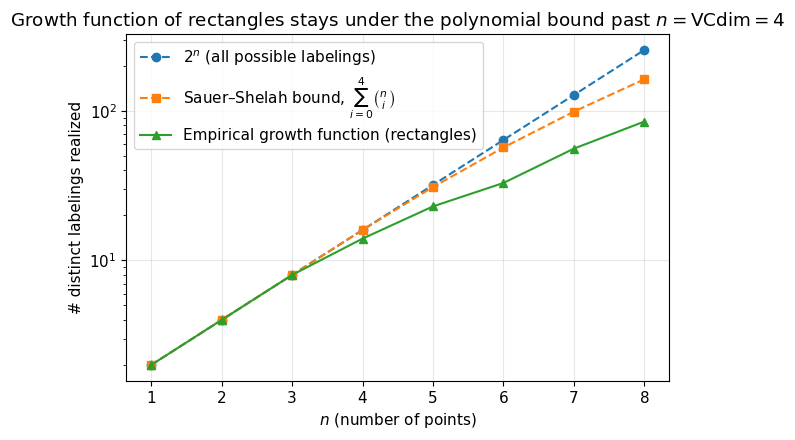

Empirical growth function values: [2, 4, 8, 14, 23, 33, 56, 85]
(Random point sets need not achieve the *maximum* growth function at every n — the plot still confirms the empirical curve never exceeds the Sauer-Shelah polynomial bound.)


In [7]:
def rectangle_growth_function(points):
    x, y = points[:, 0], points[:, 1]
    xs, ys = np.sort(np.unique(x)), np.sort(np.unique(y))
    x_gaps = np.concatenate(([xs[0] - 1], (xs[:-1] + xs[1:]) / 2, [xs[-1] + 1]))
    y_gaps = np.concatenate(([ys[0] - 1], (ys[:-1] + ys[1:]) / 2, [ys[-1] + 1]))
    labelings = set()
    for xlo in x_gaps:
        for xhi in x_gaps[x_gaps >= xlo]:
            in_x = (x >= xlo) & (x <= xhi)
            for ylo in y_gaps:
                for yhi in y_gaps[y_gaps >= ylo]:
                    inside = in_x & (y >= ylo) & (y <= yhi)
                    labelings.add(tuple(inside.astype(int)))
    return len(labelings)

ns = list(range(1, 9))
empirical, poly_bound = [], []
d = 4  # VCdim of axis-aligned rectangles
for n in ns:
    pts = np.random.uniform(0, 10, size=(n, 2))
    empirical.append(rectangle_growth_function(pts))
    poly_bound.append(sum(comb(n, i) for i in range(min(d, n) + 1)))

plt.figure()
plt.plot(ns, [2 ** n for n in ns], 'o--', label=r'$2^n$ (all possible labelings)')
plt.plot(ns, poly_bound, 's--', label=r'Sauer–Shelah bound, $\sum_{i=0}^{4}\binom{n}{i}$')
plt.plot(ns, empirical, '^-', label='Empirical growth function (rectangles)')
plt.yscale('log')
plt.xlabel('$n$ (number of points)'); plt.ylabel('# distinct labelings realized')
plt.legend(); plt.title('Growth function of rectangles stays under the polynomial bound past $n=\\mathrm{VCdim}=4$')
plt.show()
print("Empirical growth function values:", empirical)
print("(Random point sets need not achieve the *maximum* growth function at every n — the plot",
      "still confirms the empirical curve never exceeds the Sauer-Shelah polynomial bound.)")



Exactly as Sauer's Lemma predicts: growth matches $2^m$ while $m \leq 3$, then falls below
the polynomial bound once $m$ passes the VC dimension.

### D.4 The VC generalization bound

Let's just plug numbers into the bound
$R_D(h) \leq \widehat R_S(h) + C\sqrt{\frac{d\log(m/d) + \log(1/\delta)}{m}}$
and see how the "complexity term" behaves as $m$ and $d$ change.


In [ ]:
def vc_complexity_term(d, m, delta, C=1.0):
    return C * np.sqrt((d * np.log(m / d) + np.log(1 / delta)) / m)

delta = 0.05
for d in [3, 10, 50]:
    ms = np.array([100, 1000, 10000, 100000])
    terms = [vc_complexity_term(d, m, delta) for m in ms]
    print(f"VC dimension d={d:3d}:", [f"{t:.3f}" for t in terms], " (as m grows: 100 -> 100,000)")


In [ ]:
ms_fine = np.logspace(2, 5, 30)
for d in [3, 10, 50]:
    plt.plot(ms_fine, [vc_complexity_term(d, m, delta) for m in ms_fine], label=f'VC dim = {d}')
plt.xscale('log')
plt.xlabel('m (training set size)'); plt.ylabel('Complexity term')
plt.title('Bigger VC dimension needs more data for the same complexity term')
plt.legend()
plt.show()


## 2. Generalized Linear Models



In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    PoissonRegressor
)

np.random.seed(42)

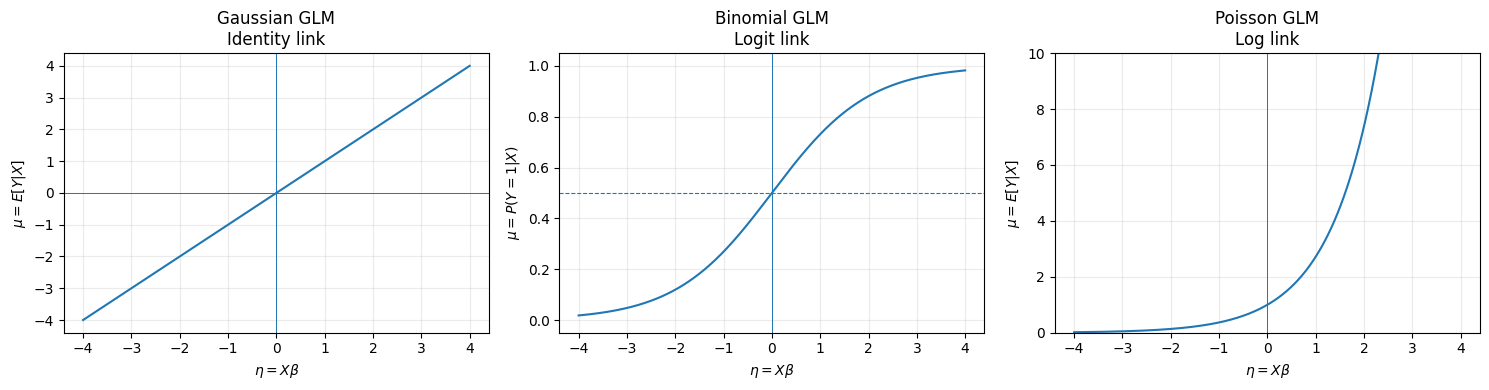

In [5]:
x = np.linspace(-4, 4, 500)

# Linear / Gaussian
mu_linear = x

# Logistic / Binomial
mu_logistic = 1 / (1 + np.exp(-x))

# Poisson
mu_poisson = np.exp(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Linear
axes[0].plot(x, mu_linear)
axes[0].axhline(0, linewidth=0.7)
axes[0].axvline(0, linewidth=0.7)
axes[0].set_title("Gaussian GLM\nIdentity link")
axes[0].set_xlabel(r"$\eta = X\beta$")
axes[0].set_ylabel(r"$\mu = E[Y|X]$")

# Logistic
axes[1].plot(x, mu_logistic)
axes[1].axhline(0.5, linestyle="--", linewidth=0.8)
axes[1].axvline(0, linewidth=0.7)
axes[1].set_title("Binomial GLM\nLogit link")
axes[1].set_xlabel(r"$\eta = X\beta$")
axes[1].set_ylabel(r"$\mu = P(Y=1|X)$")
axes[1].set_ylim(-0.05, 1.05)

# Poisson
axes[2].plot(x, mu_poisson)
axes[2].axvline(0, linewidth=0.7)
axes[2].set_title("Poisson GLM\nLog link")
axes[2].set_xlabel(r"$\eta = X\beta$")
axes[2].set_ylabel(r"$\mu = E[Y|X]$")
axes[2].set_ylim(0, 10)

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## complete GLM pipeline

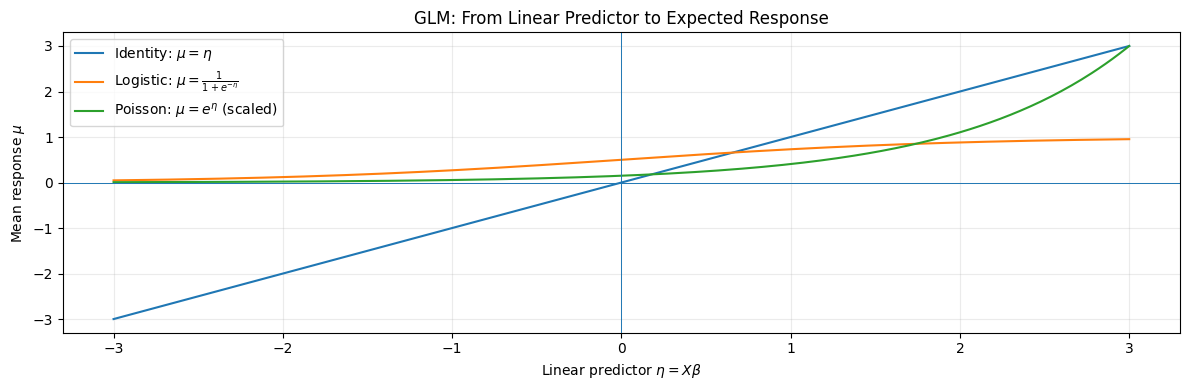

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

# Linear predictor
eta = np.linspace(-3, 3, 300)

# Three inverse links
identity = eta
sigmoid = 1 / (1 + np.exp(-eta))
poisson = np.exp(eta)

# Normalize Poisson only for visualization
poisson_scaled = poisson / np.max(poisson) * 3

ax.plot(
    eta,
    identity,
    label=r"Identity: $\mu=\eta$"
)

ax.plot(
    eta,
    sigmoid,
    label=r"Logistic: $\mu=\frac{1}{1+e^{-\eta}}$"
)

ax.plot(
    eta,
    poisson_scaled,
    label=r"Poisson: $\mu=e^\eta$ (scaled)"
)

ax.axvline(0, linewidth=0.7)
ax.axhline(0, linewidth=0.7)

ax.set_xlabel(r"Linear predictor $\eta=X\beta$")
ax.set_ylabel(r"Mean response $\mu$")
ax.set_title("GLM: From Linear Predictor to Expected Response")

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

## Logistic regression: see the GLM in action

In [7]:
n = 200

X = np.linspace(-3, 3, n)

# True probability
p_true = 1 / (1 + np.exp(-(1.5 * X - 0.5)))

# Generate binary observations
y = np.random.binomial(1, p_true)

In [9]:
model = LogisticRegression()
model.fit(X.reshape(-1, 1), y)

p_pred = model.predict_proba(
    X.reshape(-1, 1)
)[:, 1]

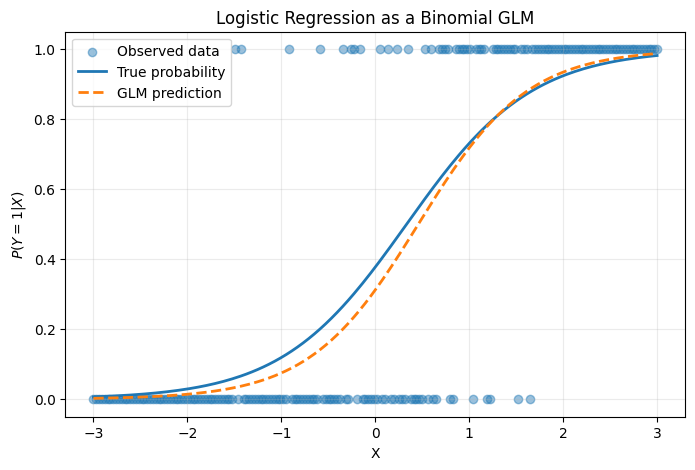

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y,
    alpha=0.45,
    label="Observed data"
)

plt.plot(
    X,
    p_true,
    linewidth=2,
    label="True probability"
)

plt.plot(
    X,
    p_pred,
    linestyle="--",
    linewidth=2,
    label="GLM prediction"
)

plt.xlabel("X")
plt.ylabel(r"$P(Y=1|X)$")
plt.title("Logistic Regression as a Binomial GLM")

plt.grid(alpha=0.25)
plt.legend()

plt.show()

## 4. Regularization

### 4.1 Ridge vs. Lasso regularization paths

Section 6.2–6.3: ridge shrinks coefficients smoothly toward 0, while lasso's $L_1$ penalty sets
coefficients *exactly* to 0 past some $\lambda$. We build a small, wide dataset ($n=60$ samples,
$p=40$ features) with a correlated block (features 0–7, the only truly relevant ones) so that both
the shrinkage behaviour and the later bias–variance and grouping effects are visible.

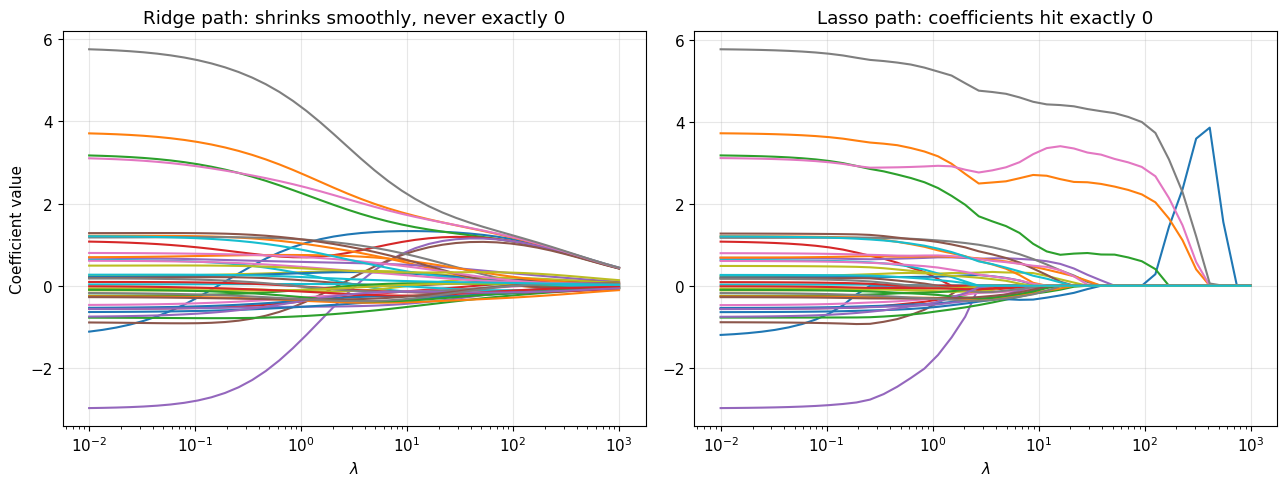

Note: a couple of lasso coefficients rise before dropping to 0 in the mid-lambda range. This is real, correlated-block competition, not a fitting artifact -- as lambda grows, lasso zeroes features in the correlated block x0..x7 one at a time, and the surviving feature(s) must temporarily carry more of the signal. Section 4.3 revisits this with elastic net.


In [ ]:
from sklearn.linear_model import Ridge, Lasso

np.random.seed(1)
n, p = 60, 40
X_reg = np.random.normal(size=(n, p))
X_reg[:, 1:8] = X_reg[:, 0:1] + np.random.normal(scale=0.3, size=(n, 7))   # correlated block
true_beta_reg = np.zeros(p); true_beta_reg[:8] = 1.5
y_reg = X_reg @ true_beta_reg + np.random.normal(scale=3.0, size=n)
X_reg_std = (X_reg - X_reg.mean(0)) / X_reg.std(0)

lambdas = np.logspace(-2, 3, 40)
ridge_coefs = np.array([Ridge(alpha=lam).fit(X_reg_std, y_reg).coef_ for lam in lambdas])
lasso_coefs = np.array([Lasso(alpha=lam / n, max_iter=50000, tol=1e-8).fit(X_reg_std, y_reg).coef_ for lam in lambdas])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for j in range(p):
    axes[0].plot(lambdas, ridge_coefs[:, j])
    axes[1].plot(lambdas, lasso_coefs[:, j])
axes[0].set_xscale('log'); axes[1].set_xscale('log')
axes[0].set_xlabel(r'$\lambda$'); axes[1].set_xlabel(r'$\lambda$')
axes[0].set_ylabel('Coefficient value')
axes[0].set_title('Ridge path: shrinks smoothly, never exactly 0')
axes[1].set_title('Lasso path: coefficients hit exactly 0')
plt.tight_layout(); plt.show()




### G.4 The geometry: circle vs. diamond

The document explains Ridge's constraint region is a circle and Lasso's is a diamond.

## Unit $L_p$ Balls

For a vector $\boldsymbol{\beta}=(\beta_1,\beta_2)$, the $L_p$ norm is defined as

$$
\|\boldsymbol{\beta}\|_p
=
\left(
|\beta_1|^p + |\beta_2|^p
\right)^{1/p},
\qquad p>0.
$$

The **unit $L_p$ ball** is the set

$$
\|\boldsymbol{\beta}\|_p \leq 1
$$

or equivalently,

$$
|\beta_1|^p + |\beta_2|^p \leq 1.
$$

The boundary plotted in the figure is therefore

$$
|\beta_1|^p + |\beta_2|^p = 1.
$$

### Important special cases

**$p=1$ — $L_1$ norm (diamond):**

$$
\|\boldsymbol{\beta}\|_1
=
|\beta_1|+|\beta_2|
$$

and the unit ball is

$$
|\beta_1|+|\beta_2|\leq 1.
$$


**$p=2$ — $L_2$ norm (circle):**

$$
\|\boldsymbol{\beta}\|_2
=
\sqrt{\beta_1^2+\beta_2^2}
$$

and the unit ball is

$$
\beta_1^2+\beta_2^2\leq 1.
$$


**$p=\infty$ — $L_\infty$ norm (square):**

$$
\|\boldsymbol{\beta}\|_\infty
=
\max\{|\beta_1|,|\beta_2|\}
$$

and the unit ball is

$$
\max\{|\beta_1|,|\beta_2|\}\leq 1,
$$

which is equivalent to

$$
|\beta_1|\leq 1,
\qquad
|\beta_2|\leq 1.
$$

### For $0<p<1$

For example, $p=0.5$:

$$
\|\boldsymbol{\beta}\|_{0.5}
=
\left(
|\beta_1|^{0.5}+|\beta_2|^{0.5}
\right)^{2}.
$$

Strictly speaking, for $0<p<1$ this is **not a norm** because the triangle inequality does not hold. It is usually called a **quasi-norm**.

The corresponding unit ball is

$$
|\beta_1|^p+|\beta_2|^p\leq 1.
$$

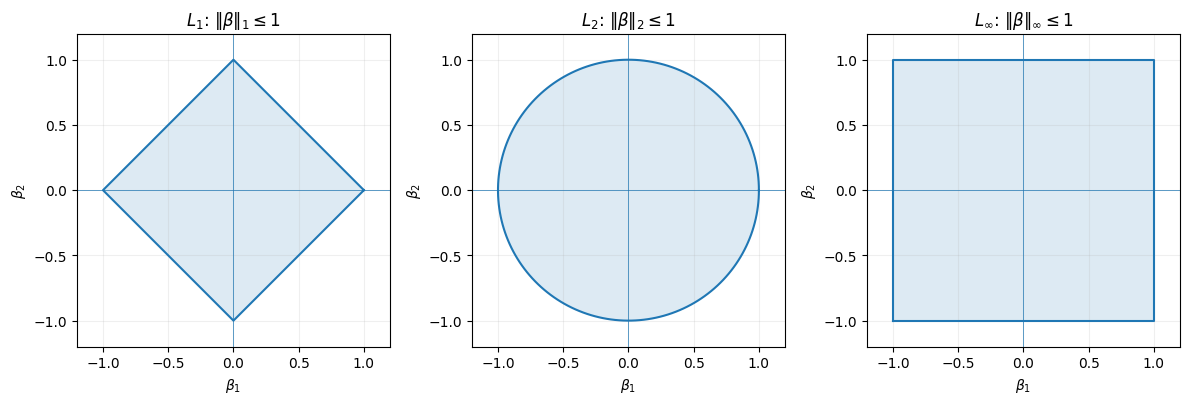

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
diamond_x = [1, 0, -1, 0, 1]
diamond_y = [0, 1, 0, -1, 0]

axes[0].plot(diamond_x, diamond_y)
axes[0].fill(diamond_x, diamond_y, alpha=0.15)

axes[0].set_title(
    r"$L_1$: $\|\beta\|_1 \leq 1$"
)


theta = np.linspace(0, 2*np.pi, 200)

circle_x = np.cos(theta)
circle_y = np.sin(theta)

axes[1].plot(circle_x, circle_y)
axes[1].fill(circle_x, circle_y, alpha=0.15)

axes[1].set_title(
    r"$L_2$: $\|\beta\|_2 \leq 1$"
)

square_x = [-1, 1, 1, -1, -1]
square_y = [-1, -1, 1, 1, -1]

axes[2].plot(square_x, square_y)
axes[2].fill(square_x, square_y, alpha=0.15)

axes[2].set_title(
    r"$L_\infty$: $\|\beta\|_\infty \leq 1$"
)

for ax in axes:
    ax.set_xlabel(r"$\beta_1$")
    ax.set_ylabel(r"$\beta_2$")

    ax.axhline(0, linewidth=0.5)
    ax.axvline(0, linewidth=0.5)

    ax.set_aspect("equal")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

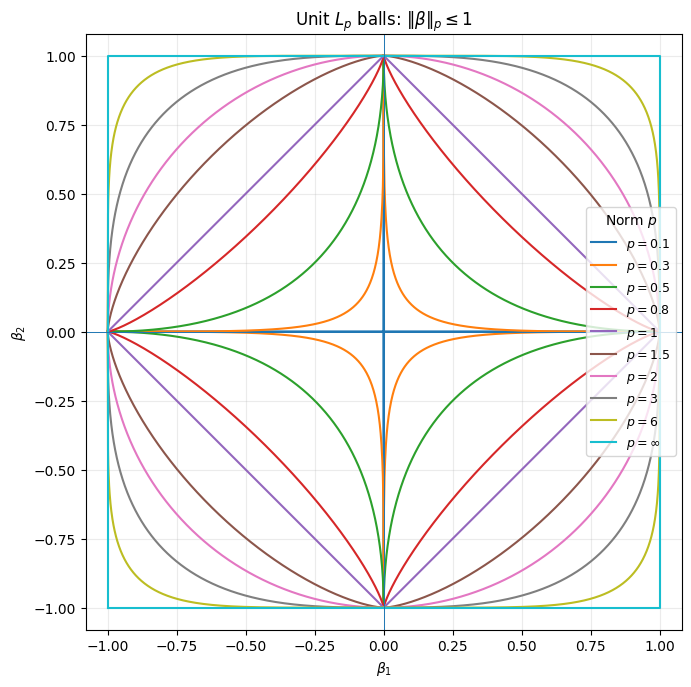

Saved plot to: plots/lp_norm_balls_same_color.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt

ps = [0.1, 0.3, 0.5, 0.8, 1, 1.5, 2, 3, 6]
fig, ax = plt.subplots(figsize=(7, 7))

# Use one fixed color for each p and apply it to all four quadrants
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

x = np.linspace(0, 1, 1000)

for p, color in zip(ps, colors):
    y = np.maximum(0, 1 - x**p)**(1/p)

    # Same color for all four quadrants
    ax.plot( x,  y, color=color, label=fr"$p={p}$")
    ax.plot(-x,  y, color=color)
    ax.plot(-x, -y, color=color)
    ax.plot( x, -y, color=color)

# L-infinity: square, with one fixed color
inf_color = colors[len(ps) % len(colors)]
ax.plot(
    [-1, 1, 1, -1, -1],
    [-1, -1, 1, 1, -1],
    color=inf_color,
    label=r"$p=\infty$"
)

ax.axhline(0, linewidth=0.7)
ax.axvline(0, linewidth=0.7)

ax.set_xlabel(r"$\beta_1$")
ax.set_ylabel(r"$\beta_2$")
ax.set_title(r"Unit $L_p$ balls: $\|\beta\|_p \leq 1$")

ax.set_aspect("equal")
ax.set_xlim(-1.08, 1.08)
ax.set_ylim(-1.08, 1.08)
ax.grid(alpha=0.25)
ax.legend(loc="right", fontsize=9, title="Norm $p$")

plt.tight_layout()

output_path = "plots/lp_norm_balls_same_color.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {output_path}")
